In [216]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
import pyopencl as cl
from pathlib import Path
import matplotlib.cm as cm
import json

%matplotlib notebook

In [217]:
def heterodyne(t,A1,A2,A3,tt1,tt2,b,w,p):
    #return 1+A*np.abs(np.exp(1j*w*t-(t/tt)**b))**2
    #return 1+A1*np.abs(A2*np.exp(-2*(t/tt1)**b) + A3*np.exp(1j*w*t-(t/tt2)))**2
    #return 1+A1*np.abs(np.exp(-2*(t/tt1)**b) + A2*np.exp(-(t/tt2))*np.cos(w*t+p)
    return 1+A1*np.abs(A2*np.exp(-2*(t/tt1)**b) + A3*np.exp(1j*w*t+p-(t/tt2)))**2

In [218]:
# Define the path to the configuration file
config_path = Path("NPS_heterodyne_config.json")

# Open and load the JSON configuration file
with open(config_path, "r") as file:
    config = json.load(file)
    #json_str = json.loads(jsonString, strict=False)

In [219]:
Temps = np.array([298])

i = 0
#t298 = Path(config.get(f"{Temps[i]}"))


with h5py.File(Path(config.get(f"{Temps[i]}")), 'r') as DATA:
    g2s = DATA['XPCS/G2_Results'][:]
    g2_errs = DATA['XPCS/G2_error'][:]
    delays = DATA['XPCS/delays'][:][0]
    dQ = DATA['XPCS/dQ'][:]
    As = np.mean(DATA['XPCS/As'][:])
    aas = np.mean(DATA['XPCS/aas'][:])

   # Cs = DATA['XPCS/Cs'][:]
    taus = np.mean(DATA['XPCS/taus'][:],axis=0)
    betas = np.mean(DATA['XPCS/betas'][:],axis=0)
    taus_err = DATA['XPCS/taus_err'][:]
    betas_err = DATA['XPCS/betas_err'][:]

    #TwoTime
    TwoTime = DATA['XPCS/TwoTime'][:]
    TwoTime_extent = DATA['XPCS/TwoTime_extent'][:]


In [220]:
taus[1]

2581.3448261499516

A1:0.4067468163627916
A2:0.6949037538377312
A3:0.42249549090853505
τ1:69.40260792097335
τ2:675.6834025712432
β:2.188962042881445
T:125.4862119580802 s
φ:23.05293690899188 degrees


<IPython.core.display.Javascript object>


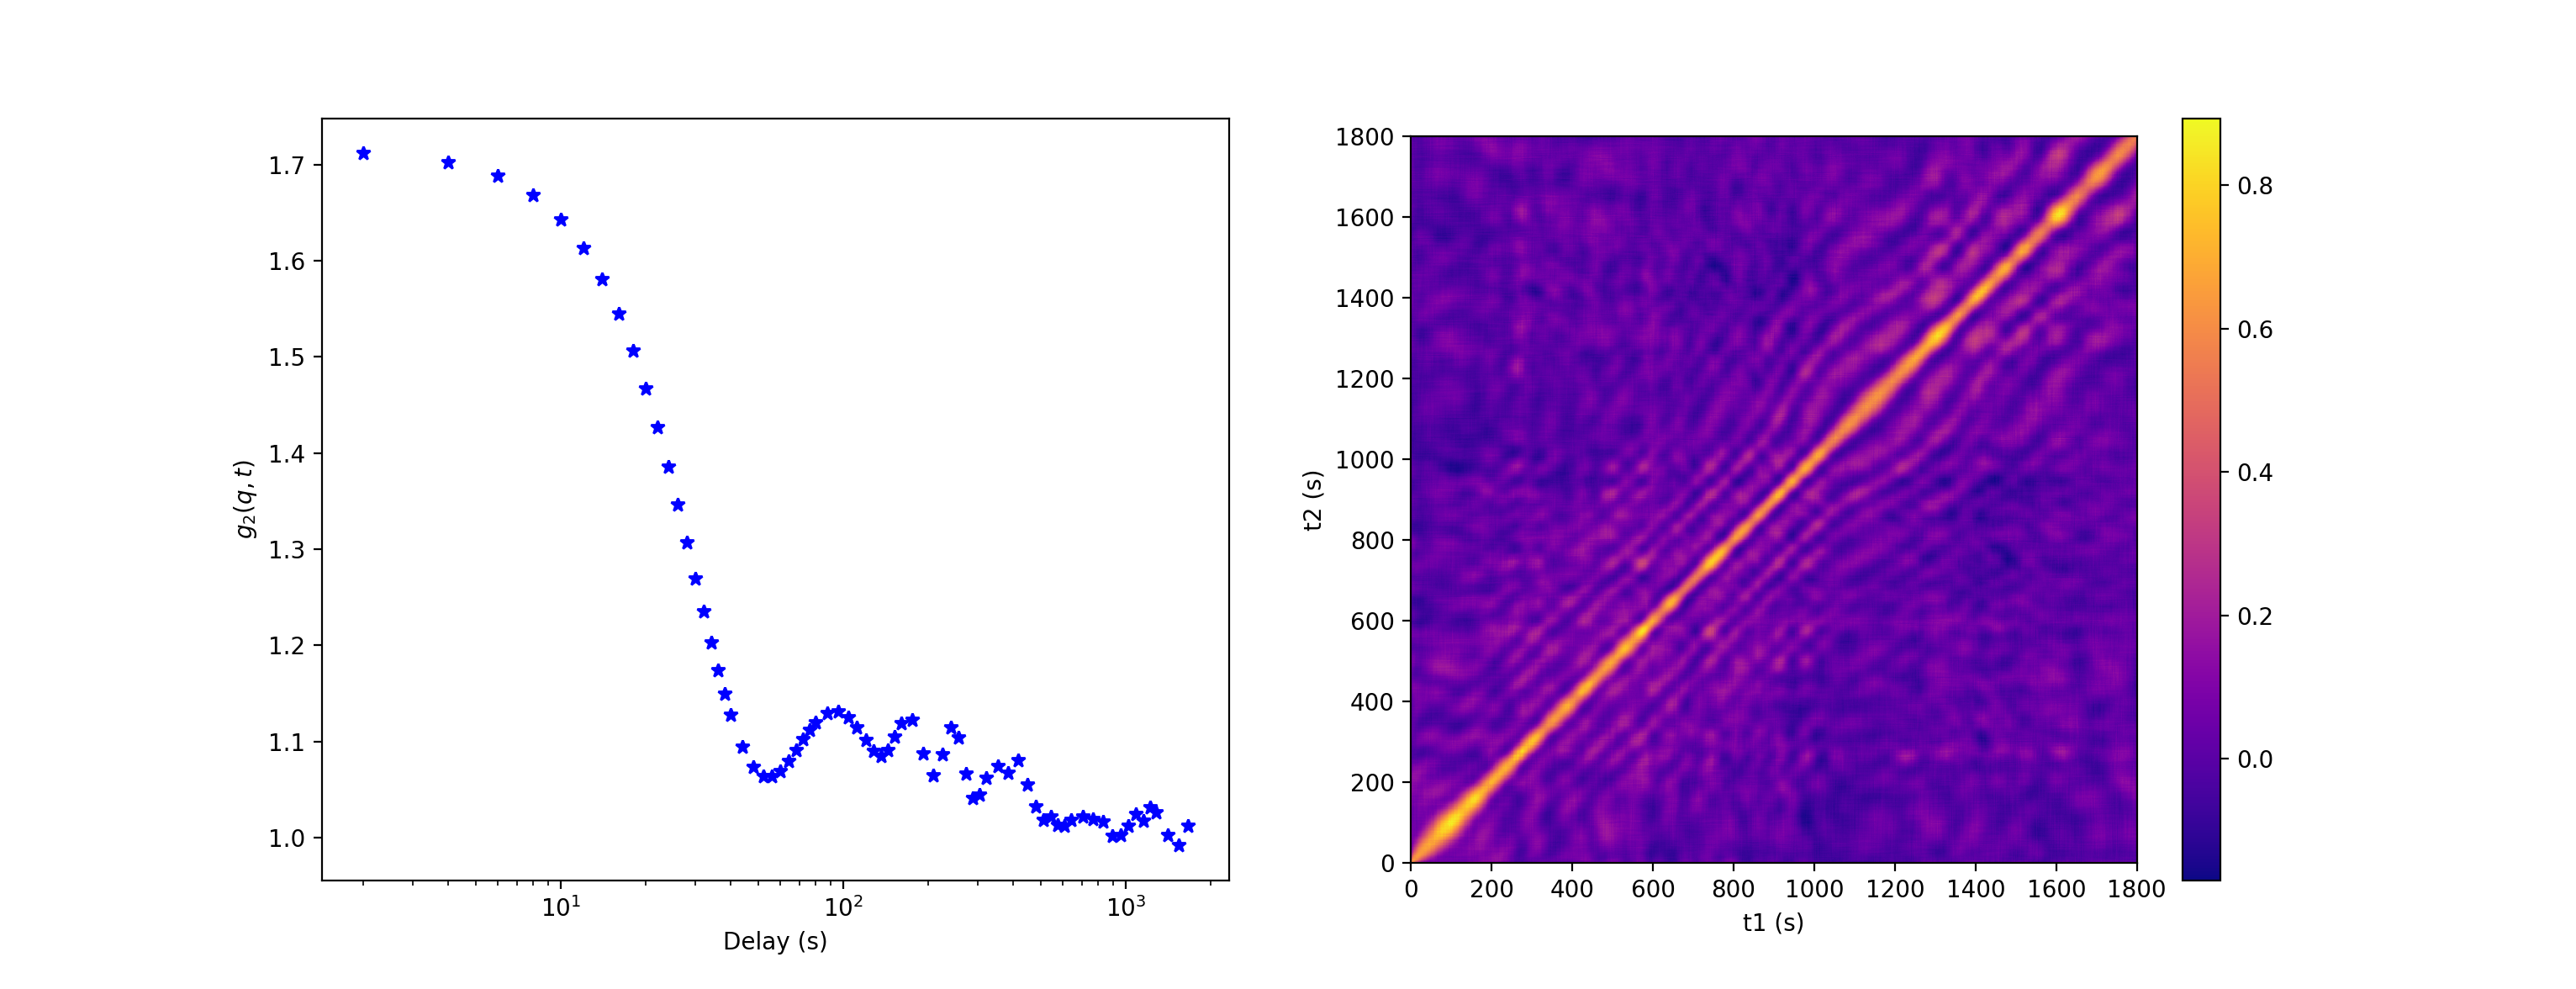

In [228]:
lower_bounds = [-np.inf,0,0,-np.inf,-np.inf,-np.inf,0,-np.inf]  # c >= 0
upper_bounds = [np.inf,np.inf,np.inf,np.inf,np.inf,np.inf,np.inf,np.inf]

i = 0
trunc = -5
#popt,pcov = curve_fit(heterodyne, delays,g2s[0,:], p0=[As,aas,1-aas,taus[0],taus[1],betas[0],2*np.pi/200], bounds=(lower_bounds, upper_bounds))
popt,pcov = curve_fit(heterodyne, delays[:trunc],g2s[i,:][:trunc], p0=[As,1-aas,aas,taus[0],taus[1],betas[0],2*np.pi/100,np.pi/2], bounds=(lower_bounds, upper_bounds))


print(f'A1:{popt[0]}')
print(f'A2:{popt[1]}')
print(f'A3:{popt[2]}')
print(f'τ1:{popt[3]}')
print(f'τ2:{popt[4]}')
print(f'β:{popt[5]}')
print(f'T:{2*np.pi/popt[-2]} s')
print(f'φ:{180*popt[-1]/np.pi} degrees')

fig,axs = plt.subplots(1,2)
axs[0].semilogx(delays,g2s[i,:],'b*')
axs[0].set_xlabel('Delay (s)')
axs[0].set_ylabel('$g_2(q,t)$')

axs[1].set_ylabel('t2 (s)')
axs[1].set_xlabel('t1 (s)')

im=axs[1].imshow(TwoTime,origin="lower",extent=TwoTime_extent,cmap='plasma')
fig.colorbar(im, ax=axs[1])


#ax.semilogx(delays,heterodyne(delays,*popt),'r')

<IPython.core.display.Javascript object>


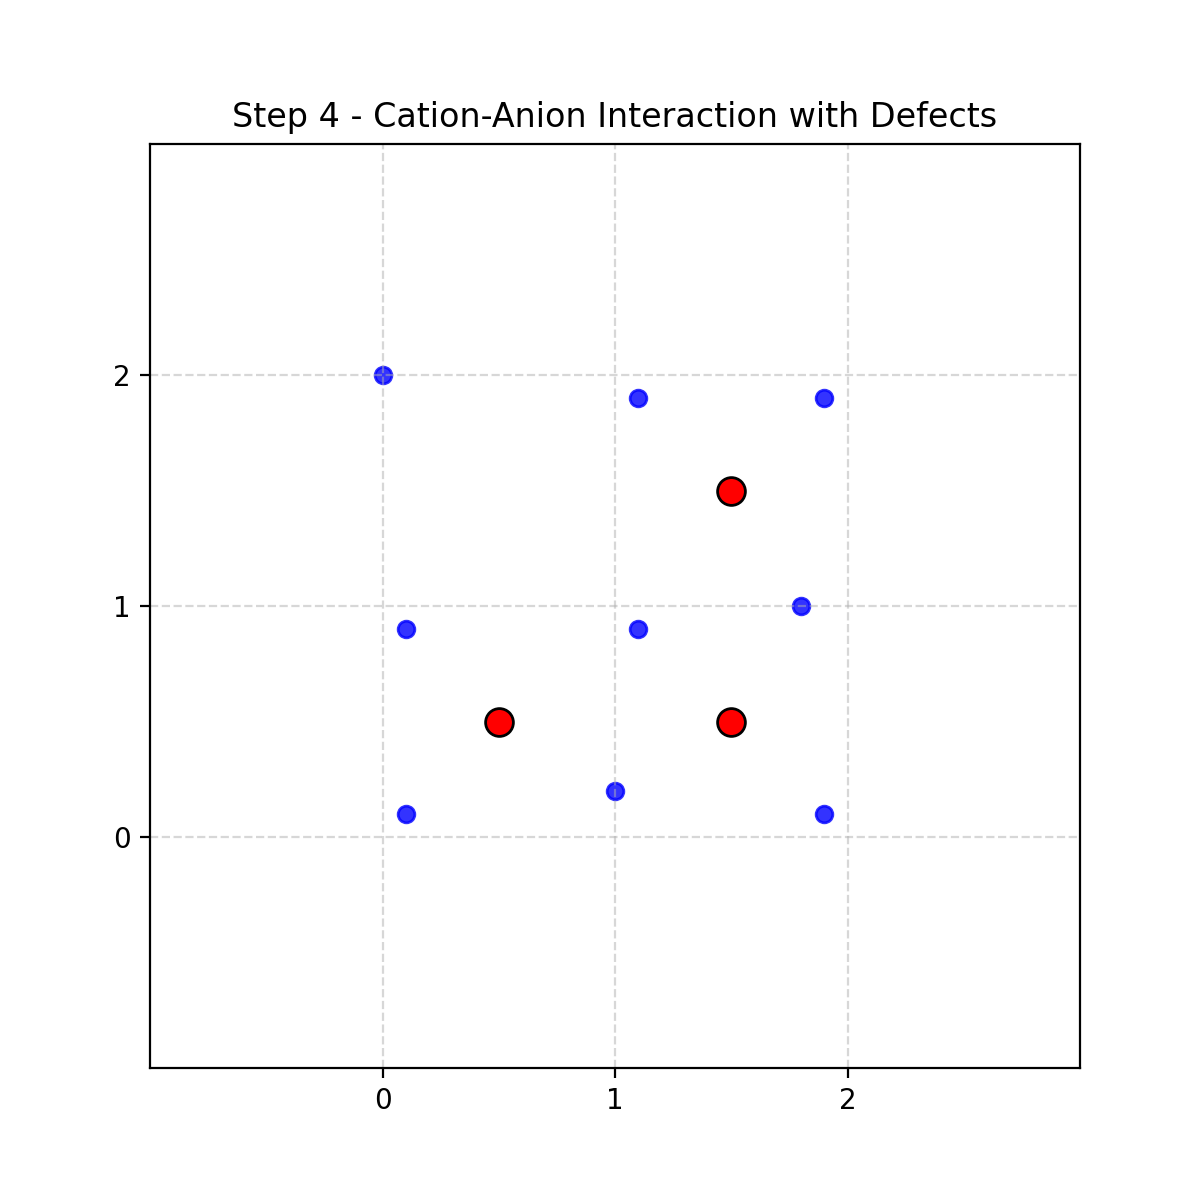

In [181]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
L = 3  # Lattice size (LxL grid)
k = 5.0  # Harmonic interaction strength
alpha = 0.2 # Strength of cation-induced anion attraction
cation_occupancy = 0.75  # Fraction of occupied cation sites
n_steps = 100  # Number of animation steps

# Initialize anion lattice (fully occupied)
anions = np.array([[i, j] for i in range(L) for j in range(L)], dtype=float)

# Initialize cation lattice (90% occupied)
cation_sites = np.array([[i + 0.5, j + 0.5] for i in range(L-1) for j in range(L-1)], dtype=float)
n_cations = int(cation_occupancy * len(cation_sites))
cations = cation_sites[np.random.choice(len(cation_sites), n_cations, replace=False)]

# Function to compute anion displacements due to cation attraction
def apply_cation_anion_interaction():
    anions_displaced = anions.copy()
    for cation in cations:
        distances = np.linalg.norm(anions - cation, axis=1)
        mask = distances < 1.1  # Nearest anion neighbors
        displacement = (cation - anions[mask]) * alpha
        anions_displaced[mask] += displacement
    return anions_displaced

# Function to update cation diffusion through vacancies
def update():
    global cations
    for i in range(len(cations)):
        move = np.random.choice([-1, 0, 1], size=2)
        new_pos = cations[i] + move
        if np.any((cation_sites == new_pos).all(axis=1)) and not np.any((cations == new_pos).all(axis=1)):
            cations[i] = new_pos  # Only move if target is a valid vacancy
    return apply_cation_anion_interaction()

# Create figure for animation
fig, ax = plt.subplots(figsize=(6,6))

def animate(i):
    ax.clear()
    displaced_anions = update()
    ax.scatter(displaced_anions[:, 0], displaced_anions[:, 1], c='b', label='Anions', alpha=0.8)
    ax.scatter(cations[:, 0], cations[:, 1], c='r', marker='o', edgecolors='black', s=100, label='Cations')
    ax.set_xlim(-1, L)
    ax.set_ylim(-1, L)
    ax.set_xticks(range(L))
    ax.set_yticks(range(L))
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title(f'Step {i} - Cation-Anion Interaction with Defects')
    #ax.legend()

ani = animation.FuncAnimation(fig, animate, frames=n_steps, interval=500)
plt.show()



In [213]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Simulation parameters
image_size = (256, 256)
time_steps = 1000
tau1=50
tau2=100
beta=1.5
dt = 0.1  # Time step size
k = 5# Wave number
omega = 2  # Angular frequency

# Create initial wave pattern with periodic boundary conditions
x = np.linspace(0, 2 * np.pi, image_size[1], endpoint=False)
y = np.linspace(0, 2 * np.pi, image_size[0], endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

# Set up figure for animation
fig, ax = plt.subplots()
wave = np.cos(k * X)*np.cos(k * Y) * np.cos(omega * 0)  # Standing wave pattern
im = ax.imshow(wave, cmap='jet', animated=True)
ax.axis('off')

def update(frame):
    global wave
    wave = np.exp(-dt*frame/tau1)**beta + np.exp(-dt*frame/tau2)*np.cos(k * X)*np.cos(k * Y) * np.cos(omega * frame * dt)  # Standing wave oscillating in time
    im.set_array(wave)
    return im,

ani = animation.FuncAnimation(fig, update, frames=time_steps, interval=50, blit=True)
plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


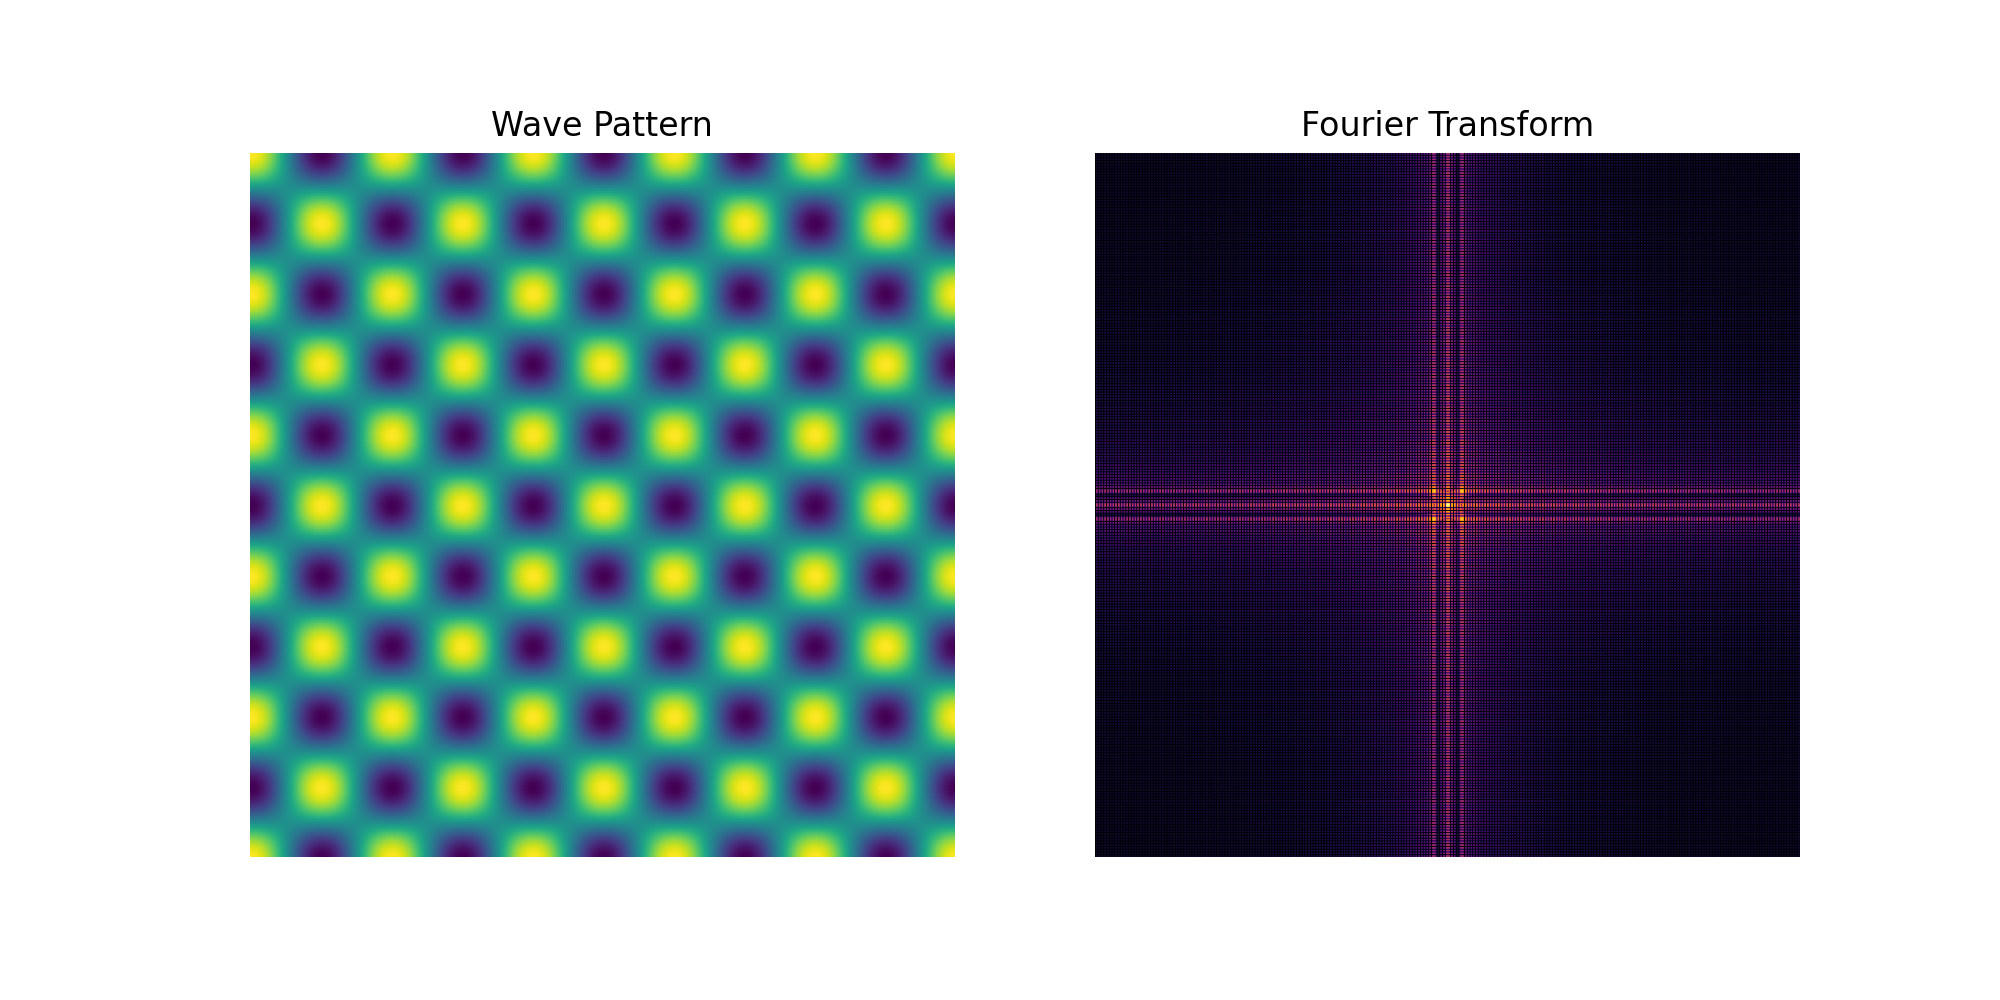

In [212]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Simulation parameters
image_size = (256, 256)
time_steps = 1000
tau1=50
tau2=100
beta=1.5
dt = 0.1  # Time step size
k = 5# Wave number
omega = 2  # Angular frequency


# Create initial wave pattern with periodic boundary conditions
x = np.linspace(0, 2 * np.pi, image_size[1], endpoint=False)
y = np.linspace(0, 2 * np.pi, image_size[0], endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

# Set up figure for animation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
wavelength = np.exp(-dt*0/tau1)**beta + np.exp(-dt*0/tau2)*np.cos(k * X)*np.cos(k * Y) * np.cos(omega * 0 * dt)  # Standing wave oscillating in time
im1 = ax1.imshow(wavelength, cmap='viridis', animated=True)
ax1.set_title('Wave Pattern')
ax1.axis('off')

# Zero padding for FFT
padded_size = (768, 768)
def pad_wave(wave):
    pad_x = (padded_size[0] - wave.shape[0]) // 2
    pad_y = (padded_size[1] - wave.shape[1]) // 2
    return np.pad(wave, ((pad_x, pad_x), (pad_y, pad_y)), mode='constant')

# Compute initial Fourier Transform
wave_padded = pad_wave(wavelength)
fft_wave = np.fft.fftshift(np.fft.fft2(wave_padded))
im2 = ax2.imshow(np.log1p(np.abs(fft_wave)), cmap='inferno', animated=True)
ax2.set_title('Fourier Transform')
ax2.axis('off')

def update(frame):
    global wavelength, fft_wave
    wavelegnth = np.exp(-dt*frame/tau1)**beta + np.exp(-dt*frame/tau2)*np.cos(k * X)*np.cos(k * Y) * np.cos(omega * frame * dt)  # Standing wave oscillating in time
    wave_padded = pad_wave(wavelength)
    fft_wave = np.fft.fftshift(np.fft.fft2(wave_padded))
    im1.set_array(wavelength)
    im2.set_array(np.log1p(np.abs(fft_wave)))
    return im1, im2

ani = animation.FuncAnimation(fig, update, frames=time_steps, interval=50, blit=False)
plt.show()